# Envelope analysis

Envelope analysis is widely used in bearing fault detection because it is very effective at identifying early-stage defects that are often hidden within normal machine vibration signals. When a bearing has damage such as cracks, spalling, or pitting on the inner race, outer race, or rolling elements, it generates repetitive high-frequency impact vibrations. Envelope analysis extracts and demodulates these high-frequency components, making the fault frequencies much easier to detect in the frequency spectrum.

First, let us open the measurement of force in the support of damaged bearing.

In [1]:
import pickle

with open("data/measurement.pkl", "rb") as f:
    data = pickle.load(f)

t = data["t"]
force = data["force"]

Now we can plot it.

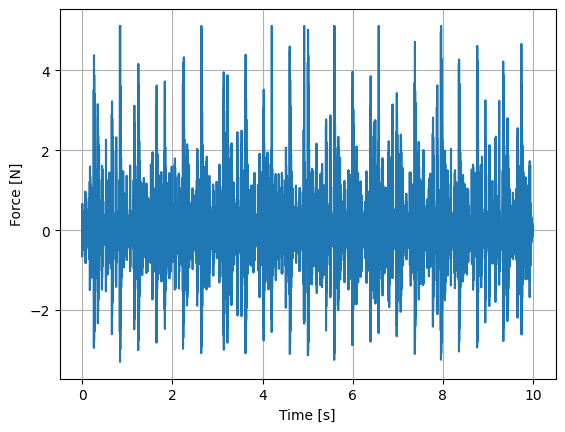

In [2]:
import matplotlib.pyplot as plt

plt.plot(t, force)
plt.xlabel("Time [s]")
plt.ylabel("Force [N]")
plt.grid()
plt.show()

Envelope can be extracted using the `envelope_extraction` method. First, the signal is filtered using a bandpass filter to isolate the resonance region. The Hilbert transform is then applied, and the absolute value of the analytic signal is taken to obtain the envelope. The most important parameter is `cutoff`, since it determines the frequency range associated with the modultaion components. Usually bandpass filter is applied around resonances where SNR is the best, therefore spectrum of raw measurement is required to determine cutoff frequencies of filter.

Fourier transform of the measured force signal is shown on the next plot.

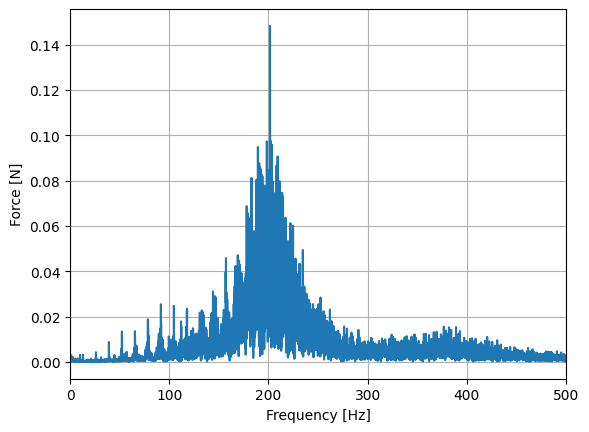

In [3]:
import numpy as np
from pybearing.signal.spectral import fft

freq, X = fft(force, fs=6400, ret_freq=True)

plt.plot(freq, np.abs(X))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Force [N]")
plt.xlim(0, 500)
plt.grid()

Given the spectrum, frequency range for bandpass filter was selected from 100 Hz to 300 Hz. Envelope together with raw signal is shown on next figure.

(1.0, 1.5)

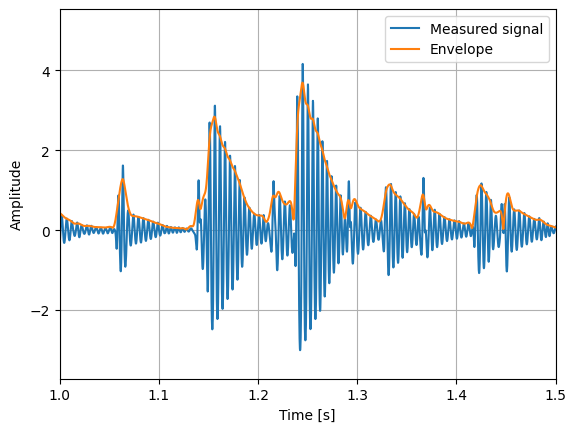

In [4]:
from pybearing.analysis.envelope_analysis import envelope_extraction

envelope = envelope_extraction(force, 6400, [100, 300], "bandpass", plot=True)
plt.xlim(1, 1.5)

After obtaining the envelope, its spectrum can be plotted and peaks at bearing-fault-characteristic frequencies can be observed. To determine the bearing-fault-characteristic frequencies, bearing internal geometry must be known or the bearing's fault-characteristic frequencies must be in the database.

`Bearing` dataclass is used to create `bearing` object.

In [5]:
from pybearing.core.bearing import Bearing

BEARING = {
    "name": "NMB_1560kk",
    "d": 6.0,
    "D": 15.0,
    "B": 5.0,
    "D_b": 2.770,
    "D_m": 10.514,
    "theta": 0.0,
    "N_b": 7,
    "bearing_type": "Deep Groove Ball Bearing",
    "manufacturer": "NMB",
}

bearing = Bearing(**BEARING)

Obtain `FaultFrequencies` by calculating them from the bearing's geometry using the function `get_fault_frequencies` from the `fault_frequencies_analysis` module. Due to fault frequencies beeing dependant on the RPMs at operating conditions, `rpm` parameter must be defined, and in our case that is 306 RPM.

In [6]:
from pybearing.analysis.fault_frequencies_analysis import get_fault_frequencies

fault_frequencies = get_fault_frequencies(bearing, 306, 1, method="geometry")

Now we can plot envelope spectrum, by first calculating PSD of envelope using function `power_spectral_density` and later plot it using the `plot_envelope_spectrum`. By providing `FaultFrequencies`, plot also generates vlines at bearing-fault-frequencies.

There are five bearing-fault-frequencies (plotted in order):
- cage
- rolling element about axis
- outer ring
- rolling element
- inner ring

Additionally, sidebands can apper in spectrum at multiples of rotational frequency $f_{rot}$. In our case frequency of rotation is $f_{rot}=5.1~\text{Hz}$. sidebands can apper at bearing-fault-frequency $\pm\,n\cdot\,f_{rot}$, where $n \in \left[1, 2, ..., \N\right]$.

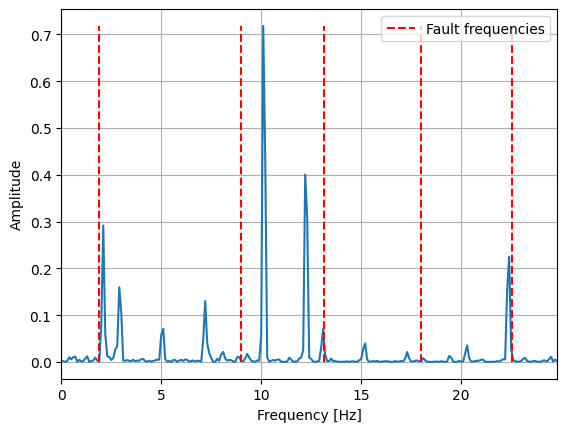

In [7]:
from pybearing.signal.spectral import power_spectral_density
from pybearing.visualization.envelope_analysis import plot_envelope_spectrum

freq, Pxx_envelope = power_spectral_density(envelope, 6400, len(envelope))
plot_envelope_spectrum(freq, Pxx_envelope, 5.1, fault_frequencies, normalise=False)